In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df= pd.read_csv('airbnb_listing_cleaned.csv')

# Summary statistics — numerical columns
# Categorical distributions
# Correlation matrix
# Plotting a bar chart for room_type and it's count
# Plotting a bar chart for room_type vs total amount

In [3]:
df.head()

,id,name,host_id,host_profile_id,host_name,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm
0,27934,Nice room with superb city view,120437.0,1462510092038582770,Nuttee,Ratchathewi,13.75983,100.54134,Entire home/apt,1573.000000,30,65.0,2024-09-17,0.38,1.0,362.0,0
1,47516,Beautiful waterfront house,214456.0,1462512829250853525,Anuradha,Don Mueang,13.92726,100.58529,Entire home/apt,2757.781687,3,0.0,NaN,0.00,1.0,365.0,0
2,48736,Condo with Chaopraya River View,222005.0,1462513037327478070,Athitaya,Rat Burana,13.68556,100.49535,Private room,1949.000000,7,1.0,2014-02-03,0.01,1.0,365.0,0
3,55681,Sathorn Terrace Apartment(61),263049.0,1462514155486597322,Tor,Bang Rak,13.71934,100.5176,Private room,2368.000000,2,44.0,2026-04-15,0.24,4.0,337.0,6
4,105042,Central Bangkok 3 Bedroom Apartment,545890.0,1462521309775343192,Henry,Khlong Toei,13.73378,100.56303,Entire home/apt,4326.000000,28,147.0,2020-01-07,0.82,1.0,332.0,0


In [8]:

# Summary statistics — numerical columns

print("Numerical summary")
print(df[['price','minimum_nights','number_of_reviews']].describe().round(2))

Numerical summary
            price  minimum_nights  number_of_reviews
count    31069.00        31069.00           31068.00
mean      2942.68           12.78              22.33
std      18405.25           34.34              61.37
min          1.00            0.00               0.00
25%       1083.00            1.00               0.00
50%       1697.00            2.00               3.00
75%       2757.78           20.00              19.00
max    1320255.00         1115.00            3447.00


In [12]:
cat_counts = df['room_type'].value_counts()
print(cat_counts)

room_type
Entire home/apt    20799
Private room        9464
Shared room          512
Hotel room           293
828                    1
Name: count, dtype: int64


In [16]:
cat_pct = (cat_counts / len(df) * 100).round(1)
print(cat_pct)

room_type
Entire home/apt    66.9
Private room       30.5
Shared room         1.6
Hotel room          0.9
828                 0.0
Name: count, dtype: float64


In [19]:
# Categorical distributions

print("Category distribution")

cat_counts = df['room_type'].value_counts()
cat_pct = (cat_counts / len(df) * 100).round(1)

print(pd.concat([cat_counts, cat_pct], axis=1, keys=['count','pct%']).to_string())


Category distribution
                 count  pct%
room_type                   
Entire home/apt  20799  66.9
Private room      9464  30.5
Shared room        512   1.6
Hotel room         293   0.9
828                  1   0.0


In [21]:
df.head()

,id,name,host_id,host_profile_id,host_name,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm
0,27934,Nice room with superb city view,120437.0,1462510092038582770,Nuttee,Ratchathewi,13.75983,100.54134,Entire home/apt,1573.000000,30,65.0,2024-09-17,0.38,1.0,362.0,0
1,47516,Beautiful waterfront house,214456.0,1462512829250853525,Anuradha,Don Mueang,13.92726,100.58529,Entire home/apt,2757.781687,3,0.0,NaN,0.00,1.0,365.0,0
2,48736,Condo with Chaopraya River View,222005.0,1462513037327478070,Athitaya,Rat Burana,13.68556,100.49535,Private room,1949.000000,7,1.0,2014-02-03,0.01,1.0,365.0,0
3,55681,Sathorn Terrace Apartment(61),263049.0,1462514155486597322,Tor,Bang Rak,13.71934,100.5176,Private room,2368.000000,2,44.0,2026-04-15,0.24,4.0,337.0,6
4,105042,Central Bangkok 3 Bedroom Apartment,545890.0,1462521309775343192,Henry,Khlong Toei,13.73378,100.56303,Entire home/apt,4326.000000,28,147.0,2020-01-07,0.82,1.0,332.0,0


In [24]:
#  Correlation matrix

corr = df[['price','minimum_nights','number_of_reviews','availability_365']].corr()
print("Correlation matrix")
print(corr.round(3))


Correlation matrix
                   price  minimum_nights  number_of_reviews  availability_365
price              1.000          -0.017             -0.002             0.006
minimum_nights    -0.017           1.000             -0.063            -0.005
number_of_reviews -0.002          -0.063              1.000            -0.069
availability_365   0.006          -0.005             -0.069             1.000


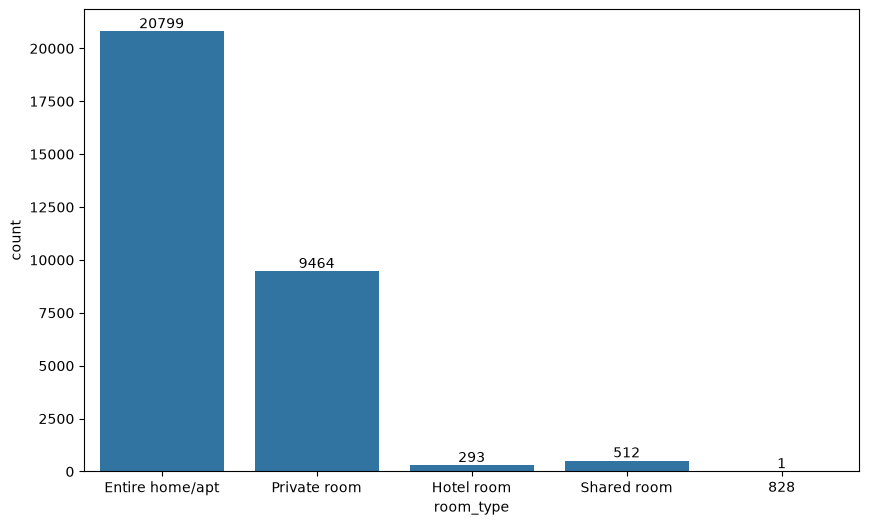

In [37]:
# plotting a bar chart for room_type and it's count

plt.figure(figsize=(10, 6))
ax= sns.countplot(data=df, x="room_type")
for bars in ax.containers:
    ax.bar_label(bars)
plt.show()

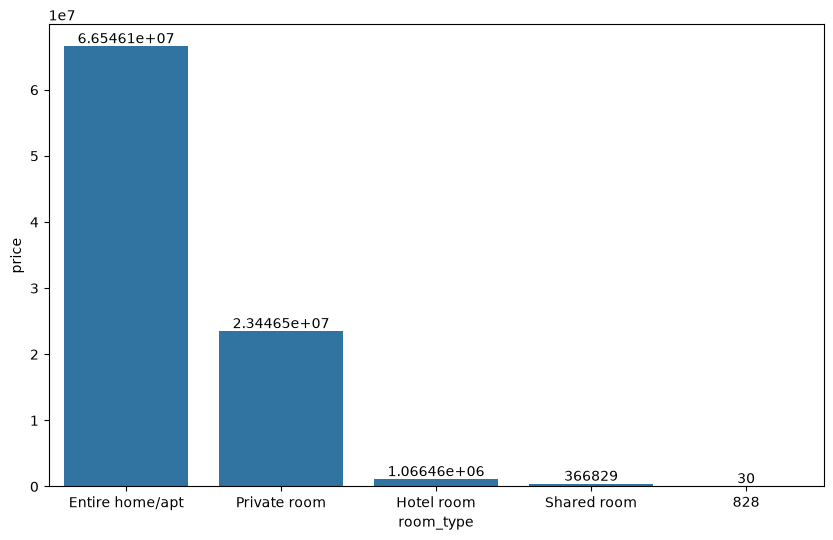

In [41]:
# plotting a bar chart for room_type vs total amount
plt.figure(figsize=(10, 6))
temp = df.groupby(['room_type'], as_index=False)['price'].sum().sort_values(by='price', ascending=False)
bx= sns.barplot(data=temp, x= 'room_type',y= 'price')
for bars in bx.containers:
    bx.bar_label(bars)
plt.show()